In [1]:
%pip install scikit-image scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import skimage
import sklearn
from sklearn import cluster
from sklearn import feature_extraction
import numpy as np
from matplotlib import pyplot as plt
import imageio
import glob

## Build Visual Vocabulary

In [2]:
paths = sorted(glob.glob('Childrens-Books/*.jpg'))
images = []
for path in paths:
    images.append(skimage.color.rgb2gray(imageio.imread(path)))

C:\tmp\ipykernel_25232\1782365333.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(skimage.color.rgb2gray(imageio.imread(path)))


In [3]:
image_descriptors = []
descriptor_extractor = skimage.feature.SIFT()
for image in images:
    descriptor_extractor.detect_and_extract(image)
    image_descriptors.append(descriptor_extractor.descriptors)

In [4]:
kmeans_descriptors = np.vstack(image_descriptors)
kmeans = sklearn.cluster.KMeans(n_clusters=1000).fit(kmeans_descriptors)

## Convert image to descriptors

In [5]:
documents = []
for descriptor in image_descriptors:
    documents.append(' '.join([str(i) for i in kmeans.predict(descriptor)]))

In [6]:
vectorizer = sklearn.feature_extraction.text.TfidfVectorizer()
histograms = vectorizer.fit_transform(documents)

In [7]:
neigh = sklearn.neighbors.NearestNeighbors(metric="cosine")
neigh.fit(histograms)

NearestNeighbors(metric='cosine')

## Test Image Search

In [8]:
query_paths = sorted(glob.glob('queries/*.jpg'))
query_images = []
for path in query_paths:
    query_images.append(skimage.color.rgb2gray(imageio.imread(path)))

C:\tmp\ipykernel_25232\2863871265.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  query_images.append(skimage.color.rgb2gray(imageio.imread(path)))


In [9]:
query_image_descriptors = []
descriptor_extractor = skimage.feature.SIFT()
for image in query_images:
    descriptor_extractor.detect_and_extract(image)
    query_image_descriptors.append(descriptor_extractor.descriptors)

In [10]:
query_documents = []
for descriptor in query_image_descriptors:
    query_documents.append(' '.join([str(i) for i in kmeans.predict(descriptor)]))

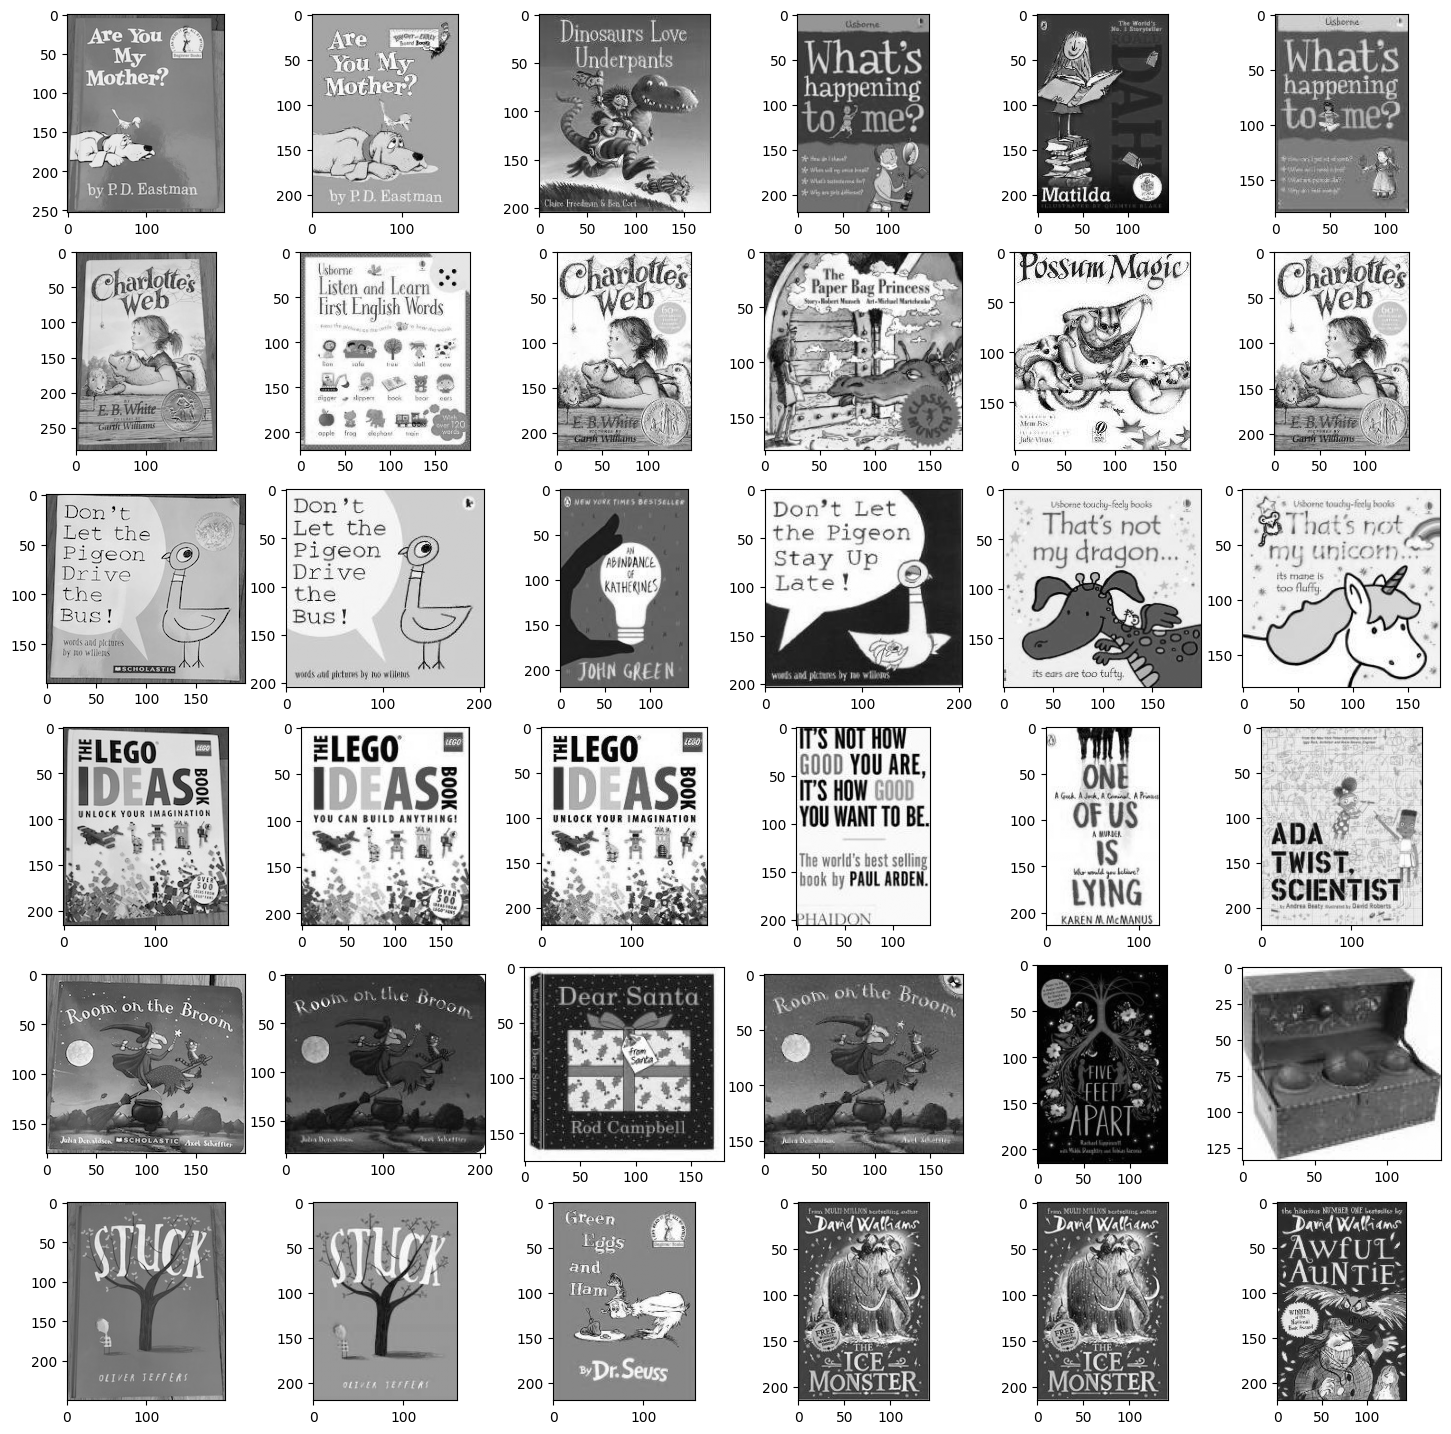

In [11]:
query_histograms = vectorizer.transform(query_documents)
distances, indices = neigh.kneighbors(query_histograms, n_neighbors=5)                                                                                                                                                                    
fig, axes = plt.subplots(len(query_images), 6, figsize=(18, 3*len(query_images)))
for i in range(len(query_images)):
    axes[i, 0].imshow(query_images[i], cmap='gray')
    for j, index in enumerate(indices[i]):
        axes[i, j+1].imshow(images[index], cmap='gray')
plt.show()

## Extra Queries

In [12]:
extra_query_paths = sorted(glob.glob('extra-queries/*.jpg'))
extra_query_images = []
for path in extra_query_paths:
    extra_query_images.append(skimage.color.rgb2gray(imageio.imread(path)))

C:\tmp\ipykernel_25232\3423115158.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  extra_query_images.append(skimage.color.rgb2gray(imageio.imread(path)))


In [13]:
extra_query_image_descriptors = []
descriptor_extractor = skimage.feature.SIFT()
for image in extra_query_images:
    descriptor_extractor.detect_and_extract(image)
    extra_query_image_descriptors.append(descriptor_extractor.descriptors)

In [14]:
extra_query_cluster_labels = []
for descriptor in extra_query_image_descriptors:
    extra_query_cluster_labels.append(kmeans.predict(descriptor))

In [15]:
extra_query_documents = []
for label in extra_query_cluster_labels:
    extra_query_documents.append(str(label))

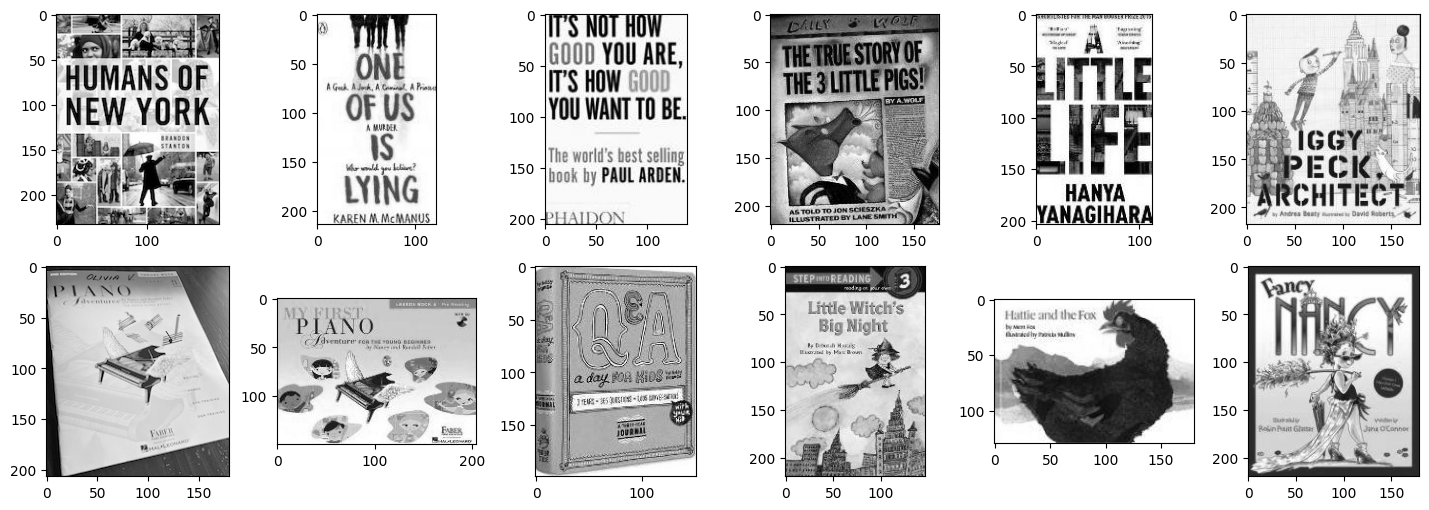

: 

In [ ]:
extra_query_histograms = vectorizer.transform(extra_query_documents)
distances, indices = neigh.kneighbors(extra_query_histograms, n_neighbors=5)                                                                                                                                                                    
fig, axes = plt.subplots(len(extra_query_images), 6, figsize=(18, 3*len(extra_query_images)))
for i in range(len(extra_query_images)):
    axes[i, 0].imshow(extra_query_images[i], cmap='gray')
    for j, index in enumerate(indices[i]):
        axes[i, j+1].imshow(images[index], cmap='gray')
plt.show()